In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path
import sys
PARENT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PARENT_ROOT))

In [4]:
from src.data.loader import load_data
from src.config import RAW_DATA_FILE_PATH
df = load_data(RAW_DATA_FILE_PATH)
df.drop(columns=["Serial No."], inplace=True)
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [5]:
df.rename({
    "GRE Score": "GRE_Score",
    "TOEFL Score": "TOEFL_Score",
    "University Rating": "University_Rating",
    "Chance of Admit ": "Chance_of_Admit",
    "LOR ": "LOR"
}, axis=1, inplace=True)
df.head()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [6]:
df.shape

(500, 8)

In [7]:
df.columns.to_list()

['GRE_Score',
 'TOEFL_Score',
 'University_Rating',
 'SOP',
 'LOR',
 'CGPA',
 'Research',
 'Chance_of_Admit']

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE_Score          500 non-null    int64  
 1   TOEFL_Score        500 non-null    int64  
 2   University_Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
 6   Research           500 non-null    int64  
 7   Chance_of_Admit    500 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 31.4 KB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
GRE_Score,500.0,316.47200,11.295148,290.00,308.0000,317.00,325.00,340.00
TOEFL_Score,500.0,107.19200,6.081868,92.00,103.0000,107.00,112.00,120.00
University_Rating,500.0,3.11400,1.143512,1.00,2.0000,3.00,4.00,5.00
SOP,500.0,3.37400,0.991004,1.00,2.5000,3.50,4.00,5.00
LOR,500.0,3.48400,0.925450,1.00,3.0000,3.50,4.00,5.00
CGPA,500.0,8.57644,0.604813,6.80,8.1275,8.56,9.04,9.92
Research,500.0,0.56000,0.496884,0.00,0.0000,1.00,1.00,1.00
Chance_of_Admit,500.0,0.72174,0.141140,0.34,0.6300,0.72,0.82,0.97


In [10]:
df.isna().sum()

GRE_Score            0
TOEFL_Score          0
University_Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance_of_Admit      0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, random_state=42)
train.to_csv("../src/data/train.csv", index=False)
test.to_csv("../src/data/test.csv", index=False)

In [13]:
X = train.drop(columns=["Chance_of_Admit"])
y = train["Chance_of_Admit"]

In [14]:
num_cols = ["GRE_Score", "TOEFL_Score", "SOP", "LOR", "CGPA"]
cat_cols = ["University_Rating", "Research"]

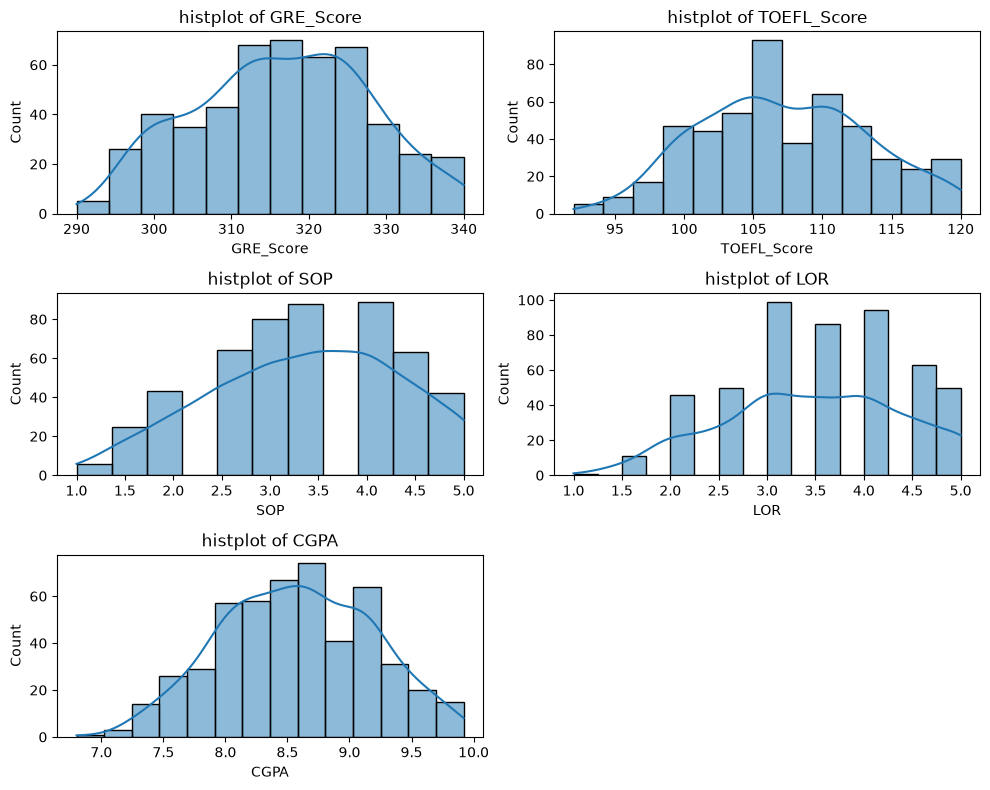

In [15]:
fig = plt.figure(figsize=(10, 8))
for i, cols in enumerate(num_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(data=df, x=cols, kde=True)
    plt.title(f"histplot of {cols}")
plt.tight_layout()
plt.show()

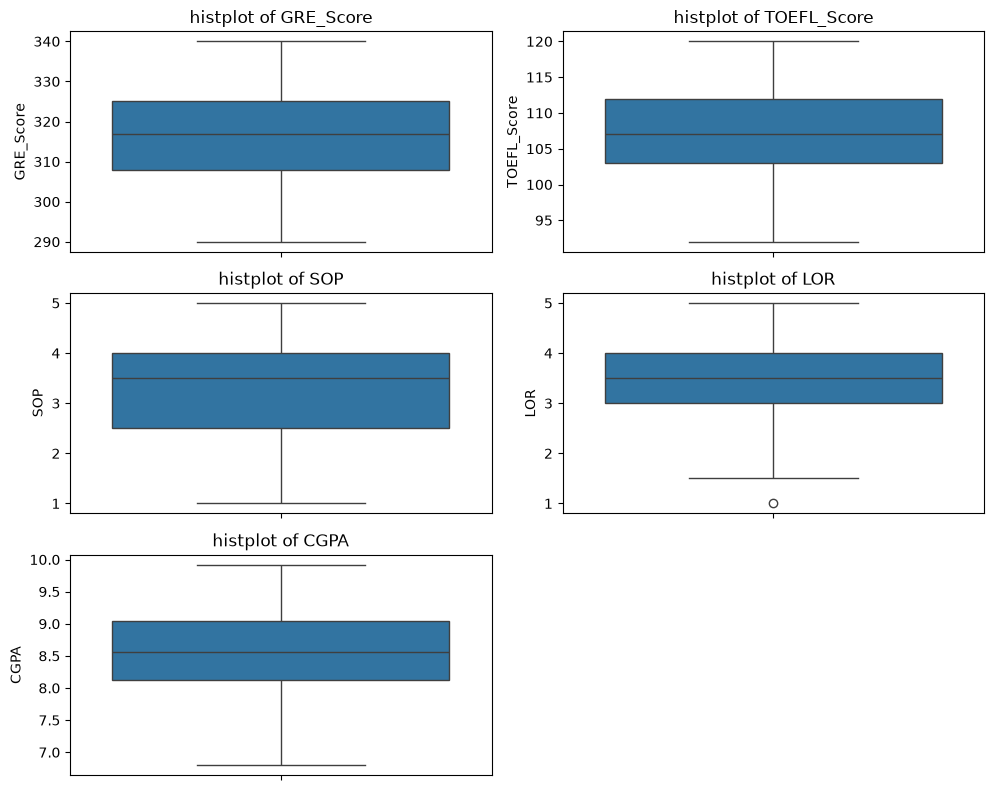

In [16]:
fig = plt.figure(figsize=(10, 8))
for i, cols in enumerate(num_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=df, y=cols)
    plt.title(f"histplot of {cols}")
plt.tight_layout()
plt.show()

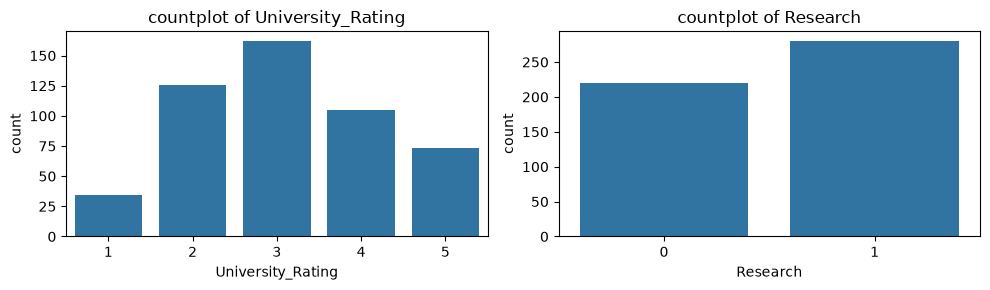

In [17]:
fig = plt.figure(figsize=(10, 3))
for i, cols in enumerate(cat_cols, 1):
    plt.subplot(1, 2, i)
    sns.countplot(data=df, x=cols)
    plt.title(f"countplot of {cols}")
plt.tight_layout()
plt.show()

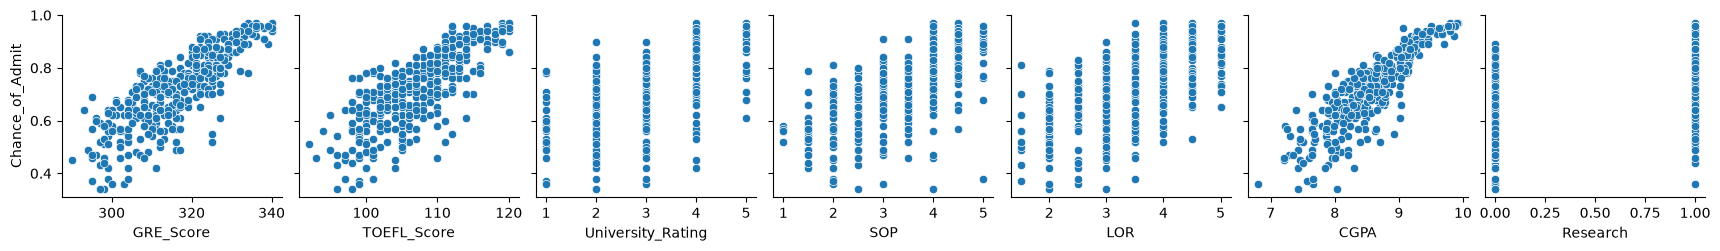

In [18]:
sns.pairplot(data=train, x_vars=X.columns, y_vars=y.name)
plt.show()

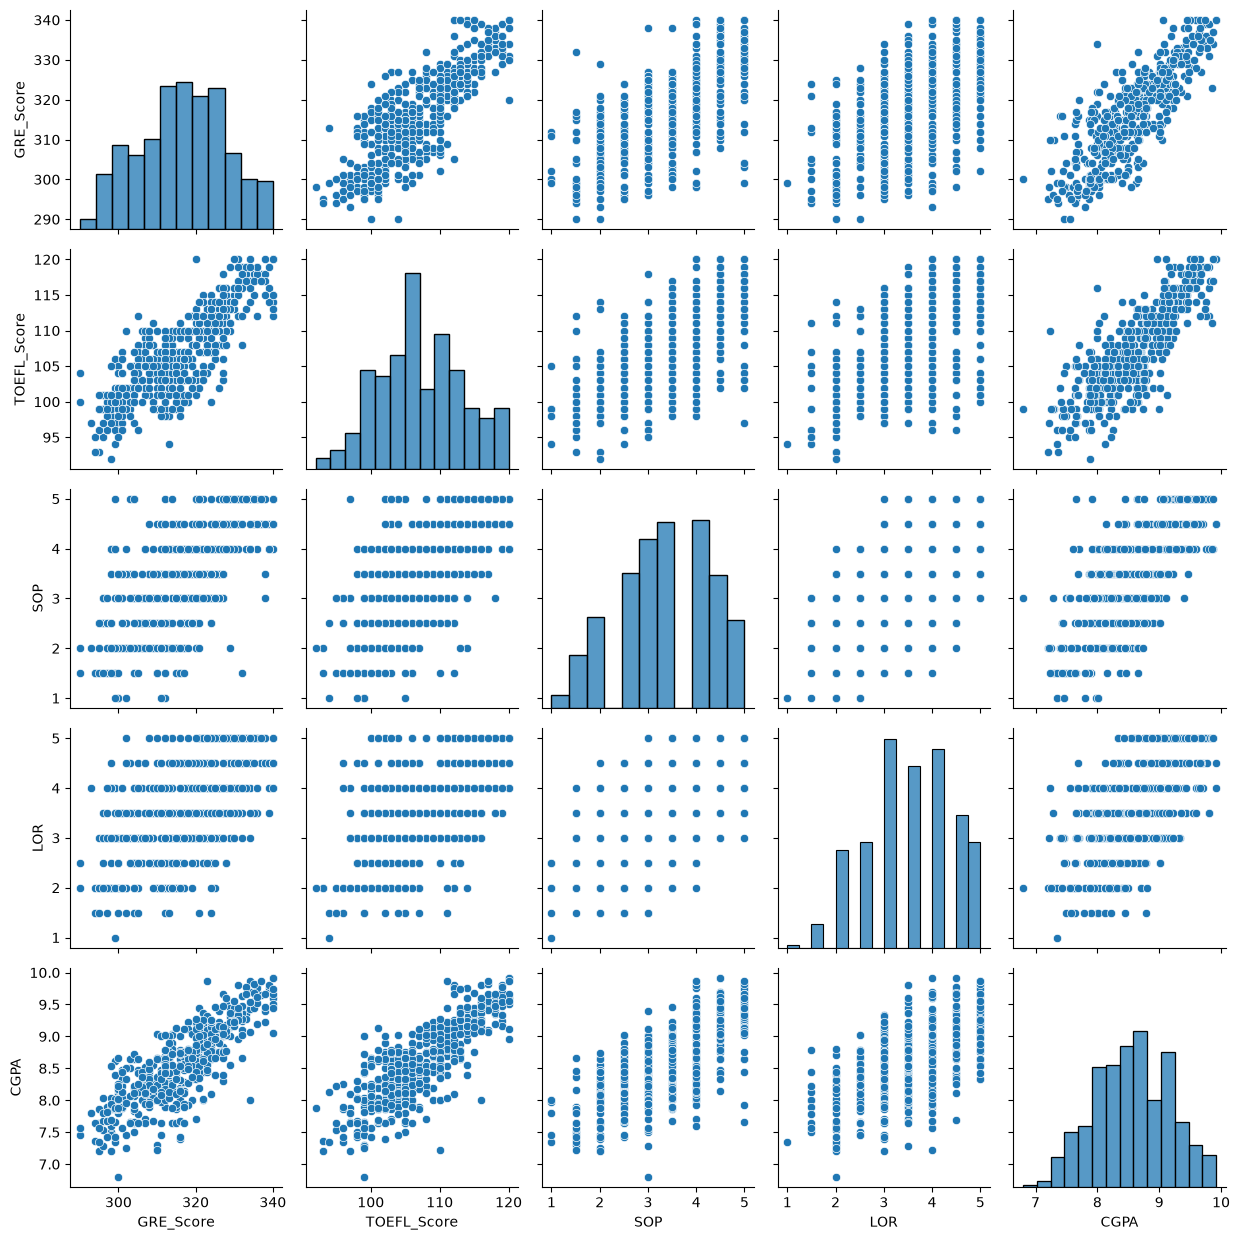

In [19]:
sns.pairplot(data=df[num_cols])
plt.tight_layout()
plt.show()

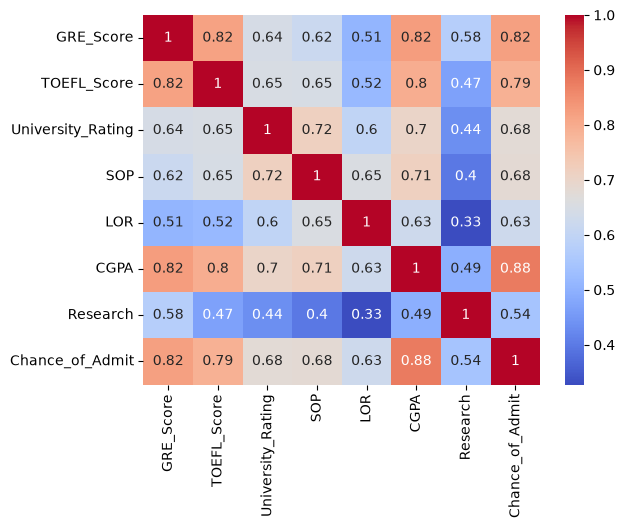

In [20]:
sns.heatmap(train.corr(), annot=True, cmap='coolwarm')
plt.show()